---
# 🛒 Desafio de Negócios: GlobalMart Analytics

**Contexto:** Você é o Engenheiro de Dados da GlobalMart. A nossa base de transações cresceu muito e a equipe de análise não está conseguindo abrir o arquivo inteiro na memória usando o método tradicional. Além disso, precisamos criar lógicas de cálculo robustas para o nosso programa de fidelidade, pois o sistema de caixas (PDV) às vezes envia dados corrompidos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração visual
sns.set_theme(style="whitegrid", context="talk")

print("⏳ A gerar arquivos CSV locais (Simulação de Big Data)...")
np.random.seed(42)

# Gerando Tabela de Lojas (Dimensão)
stores_data = {
    'StoreID': range(101, 151),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], 50),
    'StoreType': np.random.choice(['Supercenter', 'Mall', 'Street'], 50)
}
pd.DataFrame(stores_data).to_csv('stores.csv', index=False)

# Gerando Tabela de Transações MASSIVA (Fato) - 100.000 linhas
n_rows = 100000
transactions_data = {
    'TransactionID': range(1, n_rows + 1),
    'StoreID': np.random.choice(range(101, 151), n_rows),
    'ProductID': np.random.randint(1000, 5000, n_rows),
    'Price': np.random.normal(50, 15, n_rows).round(2),
    'Quantity': np.random.randint(1, 10, n_rows)
}

df_trans = pd.DataFrame(transactions_data)

# Inserindo "lixo" proposital para testar suas funções de erro
df_trans.loc[1500, 'Price'] = "ErroSistema"
df_trans.loc[8500, 'Quantity'] = -5 # Devolução inválida
df_trans.loc[45000, 'Price'] = "Corrompido"

df_trans.to_csv('transactions.csv', index=False)

print("✅ Arquivos 'stores.csv' e 'transactions.csv' gerados no disco!")
print("Tamanho do arquivo de transações:", os.path.getsize('transactions.csv') // 1024, "KB")

⏳ A gerar arquivos CSV locais (Simulação de Big Data)...


/tmp/ipykernel_5395/2746444401.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ErroSistema' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_trans.loc[1500, 'Price'] = "ErroSistema"


✅ Arquivos 'stores.csv' e 'transactions.csv' gerados no disco!
Tamanho do arquivo de transações: 2225 KB


---
**Observação:** Preste muita atenção aos seus "ofensores" passados:
*   Não coloque parênteses em atributos.
*   Lembre do case sensitive (maiúsculas e minúsculas).
*   Sintaxe rigorosa no `.loc` e no `sns`.

Boa sorte, Cientista! Mostre o que sabe fazer.

## As Requisições da Diretoria:

### 1. Engenharia de Dados: Ingestão em Chunks e Comprehensions**
*   **O Problema:** Não podemos carregar o `transactions.csv` todo de uma vez.
*   **A Demanda:** Leia o arquivo `transactions.csv` em blocos (chunks) de **10.000 linhas**.
*   Para *cada bloco*, você deve criar uma nova coluna chamada `Revenue`.
*   **Obrigatório:** A diretoria de engenharia exige que o cálculo da coluna `Revenue` (`Price` * `Quantity`) seja feito combinando a função `zip()` com uma **List Comprehension** dentro do loop do chunk.
*   Concatene os blocos processados num único DataFrame chamado `df_master`.

In [2]:
read_transactions = pd.read_csv("transactions.csv", chunksize = 10000)
df_master = pd.DataFrame()

for chunk in read_transactions:
  chunk['Price'] = pd.to_numeric(chunk['Price'], errors='coerce')
  chunk['Price'] = chunk['Price'].apply(lambda x: 0.0 if pd.isna(x) or x < 0 else x)
  bd_revenue = zip(chunk["Price"],chunk["Quantity"])
  rev_list = list(bd_revenue)
  chunk["Revenue"] = [(bd_revenue0 * bd_revenue1) for bd_revenue0, bd_revenue1 in rev_list]
  df_master = pd.concat([df_master,chunk])

In [3]:
df_master.head()

,TransactionID,StoreID,ProductID,Price,Quantity,Revenue
0,1,116,4791,44.43,4,177.72
1,2,145,3163,28.13,4,112.52
2,3,118,3647,39.90,8,319.20
3,4,147,4593,37.10,9,333.90
4,5,124,2503,14.24,8,113.92


### 2. Integração e Indexação (Foco em Sintaxe Correta)**
*   **O Problema:** Precisamos saber em qual região cada venda ocorreu.
*   **A Demanda:** Traga os dados do arquivo `stores.csv` e junte-os ao seu `df_master`.
*   Após a junção, defina a coluna `Region` como o **Índice** do DataFrame.
*   **Obrigatório:** Utilizando exclusivamente o método `.loc`, extraia um sub-dataframe contendo apenas as vendas da região `'South'` e chame-o de `df_south`.

In [4]:
read_stores = pd.read_csv("stores.csv", chunksize = 10000)
df_stores = pd.DataFrame()

for chunk in read_stores:
  df_stores = pd.concat([df_stores, chunk])

In [5]:
print(df_master.columns)
print(df_stores.columns)

Index(['TransactionID', 'StoreID', 'ProductID', 'Price', 'Quantity',
       'Revenue'],
      dtype='object')
Index(['StoreID', 'Region', 'StoreType'], dtype='object')


In [6]:
df_master = df_master.merge(df_stores, on = "StoreID")

In [7]:
df_master.reset_index()
df_master = df_master.set_index("Region")

In [8]:
df_south = df_master.loc["South"]

In [9]:
# df_south.sample(50)

### 3. Regra de Negócio: Cálculo de Pontos (User-Defined Functions & Try/Except)**
*   **O Problema:** O time de Marketing quer dar "Pontos de Fidelidade" pelas compras. A fórmula é: `Pontos = Revenue * Multiplicador`. No entanto, como avisado, a coluna `Revenue` pode ter textos (como "ErroSistema") ou as quantidades podem ter gerado faturamentos negativos.
*   **A Demanda:** Crie uma função robusta chamada `calculate_points(revenue, multiplier=1.5)`.
    *   Se o valor for negativo, use o comando `raise` para levantar um `ValueError` com uma mensagem adequada.
    *   Use `try/except` para tentar fazer a matemática. Se ocorrer um erro de tipo (TypeError) porque o valor era uma *string*, a função deve retornar `0`.
    *   Escreva uma *Docstring* profissional para esta função.

In [10]:
#Assumindo que o dataset tem valores negativos, vou trata-los antes para que não tenham. Dessa forma,
# o raise irá capturar apenas os valores que o tratamento por algum moptivo deixe passar.

In [11]:
def calculate_points(revenue, multiplier = 1.5):
  """ Retorna a quantidade de pontos por operação."""

  try:
    if revenue < 0:
      return 0
      # raise ValueError("Cálculo com valor negativo")
    return revenue * multiplier

  except TypeError:
    return 0


### 4. Aplicação Funcional (Lambdas)**
*   **A Demanda:** Aplique a função `calculate_points` criada no passo 3 ao seu DataFrame principal (`df_master`), criando a coluna `Loyalty_Points`.
*   **Obrigatório:** Você deve aplicar a função utilizando uma expressão `lambda` e o método `.apply()`. Considere que estamos numa campanha especial e o `multiplier` a ser passado na lambda deve ser `2.0`.

In [12]:
df_master["Loyality_Points"] = df_master["Revenue"].apply(lambda x: calculate_points(x,2))

In [13]:
# df_master.sample(50)

### 5. Auditoria de Colunas (Atributos e Dictionary Comprehensions)**
*   **A Demanda:** A governança de dados pediu um relatório rápido das colunas.
*   **Obrigatório:** Acesse o **atributo** que contém os nomes das colunas do seu `df_master`.
*   Crie um dicionário usando *Dictionary Comprehension* onde a **chave** seja o nome da coluna e o **valor** seja a quantidade de valores nulos (NaN) que existem apenas naquela coluna. Imprima o dicionário.

In [14]:
invalidos_p_coluna = {col: df_master[col].isna().sum() for col in df_master.columns}

In [15]:
invalidos_p_coluna

{'TransactionID': np.int64(0),
 'StoreID': np.int64(0),
 'ProductID': np.int64(0),
 'Price': np.int64(0),
 'Quantity': np.int64(0),
 'Revenue': np.int64(0),
 'StoreType': np.int64(0),
 'Loyality_Points': np.int64(0)}

### 6. Visualização Padrão Ouro (Seaborn)**
*   **A Demanda:** "Queremos um gráfico que mostre a relação entre o Preço do Produto (Eixo X) e a Quantidade comprada (Eixo Y), mas queremos ver isso separado pelas diferentes Categorias de Loja (`StoreType`)."
*   **Obrigatório:** Utilize a função de nível de eixo correta do **Seaborn** para gráficos de dispersão (scatter). Use a cor (hue) para separar por `StoreType`. Garanta que o gráfico tenha um título legível.

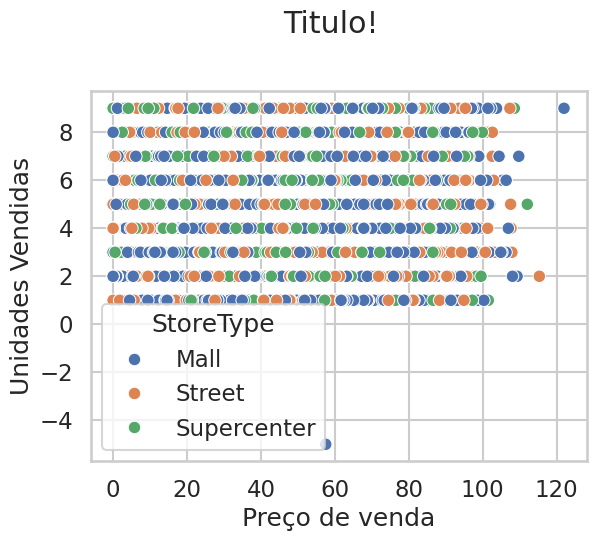

In [16]:
g = sns.scatterplot(x = "Price", y = "Quantity", data = df_master, hue = "StoreType")
g.figure.suptitle("Titulo!", y = 1.05)
g.set(xlabel = "Preço de venda", ylabel = "Unidades Vendidas")

plt.show()